In [18]:
import sys
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Trỏ đường dẫn để import được thư viện trong folder src
sys.path.append('../src') 
from cluster_library import RuleBasedCustomerClusterer

# 1. Load dữ liệu giao dịch đã làm sạch
# Lưu ý: Dựa vào ảnh của bạn, file này nằm trong data/processed
df_trans = pd.read_csv('../data/processed/cleaned_uk_data.csv')

# 2. Load luật kết hợp (Bạn đang có cả Apriori và FP-Growth, dùng FP-Growth cho xịn)
df_rules = pd.read_csv('../data/processed/rules_fpgrowth_filtered.csv')

print("Data Transaction:", df_trans.shape)
print("Data Rules:", df_rules.shape)

Data Transaction: (485123, 11)
Data Rules: (21, 17)


In [19]:
# --- CELL 2: LOAD LUẬT VÀ TẠO MA TRẬN ĐẶC TRƯNG (FINAL FIX) ---
from ast import literal_eval
import pandas as pd

# 1. Hàm xử lý: Chuyển chuỗi về dạng SET (Tập hợp) để dùng được hàm .issubset()
def parse_rule_set(rule_str):
    try:
        if isinstance(rule_str, str):
            # Chuyển chuỗi "frozenset({'A'})" thành set {'A'}
            return set(eval(rule_str)) 
        return set(rule_str)
    except:
        return set()

# 2. Áp dụng sửa lỗi format cho df_rules
print("🛠 Đang chuẩn hóa dữ liệu Luật...")
df_rules['antecedents'] = df_rules['antecedents'].apply(parse_rule_set)

# 3. Khởi tạo và Load luật
clusterer = RuleBasedCustomerClusterer()
top_k = 50 

# Dùng metric='support' để lấy 50 luật phổ biến nhất
clusterer.load_top_rules(df_rules, top_k=top_k, metric='support') 

print(f"✅ Đã load top {top_k} luật phổ biến.")

# 4. Xây dựng ma trận đặc trưng
# QUAN TRỌNG: Vẫn giữ item_col='Description' để khớp với tên sản phẩm trong luật
print("⏳ Đang tạo ma trận đặc trưng (Matching theo Tên sản phẩm)...")
df_features = clusterer.build_customer_feature_matrix(
    df_trans, 
    customer_col='CustomerID', 
    item_col='Description' 
)

# 5. Kiểm tra kết quả
total_true = df_features.sum().sum()
print(f"Kích thước ma trận: {df_features.shape}")
print(f"Tổng số ô True: {total_true}")

if total_true > 0:
    print("🎉 THÀNH CÔNG! Ma trận đã có dữ liệu. Hãy chạy tiếp các cell dưới.")
else:
    print("❌ VẪN LỖI. Kiểm tra lại dữ liệu df_trans['Description'] có khớp text với luật không.")

df_features.head()

🛠 Đang chuẩn hóa dữ liệu Luật...
✅ Đã load 21 luật dựa trên support cao nhất.
✅ Đã load top 50 luật phổ biến.
⏳ Đang tạo ma trận đặc trưng (Matching theo Tên sản phẩm)...
⏳ Đang tạo đặc trưng từ luật cho từng khách hàng (bước này tốn chút thời gian)...
✅ Đã tạo xong vector đặc trưng. Shape: (3921, 21)
Kích thước ma trận: (3921, 21)
Tổng số ô True: 8113
🎉 THÀNH CÔNG! Ma trận đã có dữ liệu. Hãy chạy tiếp các cell dưới.


,Rule_0,Rule_1,Rule_2,Rule_3,Rule_4,Rule_5,Rule_6,Rule_7,Rule_8,Rule_9,...,Rule_11,Rule_12,Rule_13,Rule_14,Rule_15,Rule_16,Rule_17,Rule_18,Rule_19,Rule_20
000nan,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
012346,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
012747,1,1,0,0,1,0,1,1,0,0,...,0,1,0,0,0,0,0,0,0,0
012748,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
012749,0,0,1,1,0,0,0,0,0,0,...,1,0,1,1,0,0,1,1,0,0


In [21]:
# Tính toán RFM từ dữ liệu giao dịch
df_trans['InvoiceDate'] = pd.to_datetime(df_trans['InvoiceDate'])
last_date = df_trans['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_trans.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (last_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                              # Frequency
    'UnitPrice': 'sum'                                   # Monetary (Giả định UnitPrice là doanh thu nếu ko có cột Total)
}).rename(columns={'InvoiceDate': 'Recency', 'InvoiceNo': 'Frequency', 'UnitPrice': 'Monetary'})

# Ghép RFM vào bộ dữ liệu (trọng số 2.0 để ưu tiên RFM hơn Rules một chút)
clusterer.add_rfm_features(rfm, weight=2.0)

⏳ Đang ghép dữ liệu RFM...
✅ Đã ghép thêm RFM. Shape mới: (3921, 24)


--------------------------------------------------
📊 [BIẾN THỂ 2] Đánh giá mô hình KẾT HỢP LUẬT + RFM
--------------------------------------------------
⏳ Đang chạy thử nghiệm K từ 2 đến 8...
   K=2 -> Silhouette=0.4717
   K=3 -> Silhouette=0.2735
   K=4 -> Silhouette=0.3391
   K=5 -> Silhouette=0.3698
   K=6 -> Silhouette=0.3831
   K=7 -> Silhouette=0.4100
   K=8 -> Silhouette=0.3414


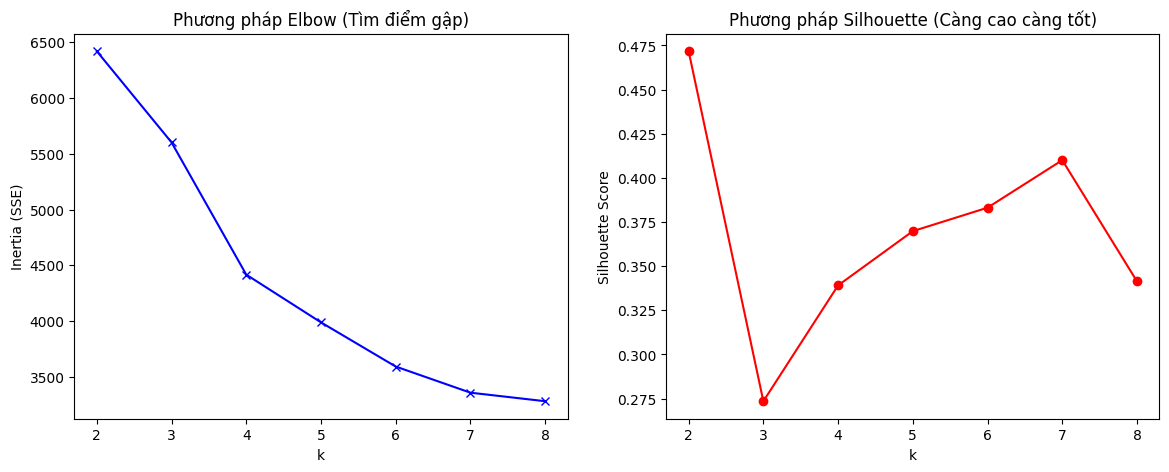


👉 So sánh chỉ số Silhouette này với bước trước để kết luận biến thể nào tốt hơn.


In [22]:
# --- ĐÁNH GIÁ BIẾN THỂ 2 (LUẬT + RFM) ---
print("-" * 50)
print("📊 [BIẾN THỂ 2] Đánh giá mô hình KẾT HỢP LUẬT + RFM")
print("-" * 50)

# Hàm này bây giờ sẽ chạy trên dữ liệu đã được thêm RFM ở bước trên
clusterer.choose_k_elbow_silhouette(k_range=range(2, 9))

print("\n👉 So sánh chỉ số Silhouette này với bước trước để kết luận biến thể nào tốt hơn.")

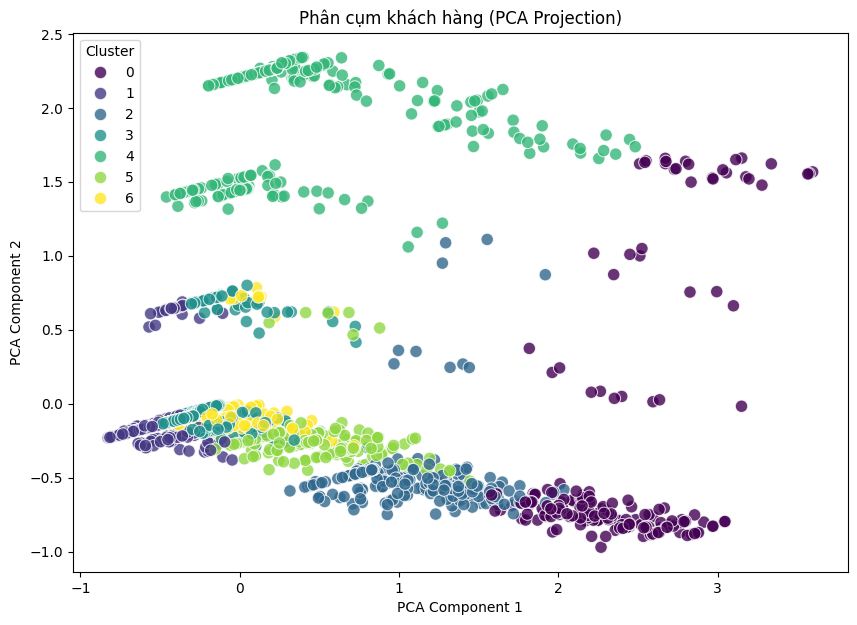

Hồ sơ trung bình của các cụm:


,Rule_0,Rule_1,Rule_2,Rule_3,Rule_4,Rule_5,Rule_6,Rule_7,Rule_8,Rule_9,...,Rule_14,Rule_15,Rule_16,Rule_17,Rule_18,Rule_19,Rule_20,Recency,Frequency,Monetary
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.995327,0.728972,0.149533,0.186916,0.995327,0.607477,0.995327,0.518692,0.803738,0.934579,...,0.219626,0.789720,0.934579,0.186916,0.121495,0.350467,0.336449,0.149132,0.028371,0.012200
1,0.000000,0.016270,0.011264,0.012516,0.000000,0.016270,0.000000,0.016270,0.016270,0.003755,...,0.020025,0.013767,0.003755,0.012516,0.003755,0.000000,0.002503,1.345898,0.000708,0.000200
2,1.000000,0.311321,0.012579,0.018868,1.000000,0.220126,1.000000,0.283019,0.081761,0.075472,...,0.075472,0.113208,0.075472,0.018868,0.012579,0.188679,0.144654,0.377106,0.006221,0.000791
3,0.000000,0.019001,0.006515,0.024430,0.000000,0.020087,0.000000,0.036374,0.036374,0.000000,...,0.060261,0.027687,0.000000,0.024430,0.003800,0.000000,0.000000,0.239671,0.003750,0.000424
4,0.107383,0.043624,0.969799,0.902685,0.107383,0.063758,0.107383,0.077181,0.077181,0.100671,...,0.124161,0.073826,0.100671,0.902685,0.848993,0.104027,0.100671,0.394156,0.008164,0.001190
5,0.000000,0.085859,0.015152,0.015152,0.000000,0.106061,0.000000,0.106061,0.520202,1.000000,...,0.101010,0.474747,1.000000,0.015152,0.000000,0.161616,0.146465,0.363555,0.006354,0.000955
6,0.000000,0.031746,0.007937,0.035714,0.000000,0.051587,0.000000,0.091270,0.091270,0.000000,...,0.091270,0.059524,0.000000,0.035714,0.003968,0.785714,0.658730,0.233989,0.005322,0.000880


Số lượng khách hàng mỗi cụm:
Cluster
3    1842
1     799
2     318
4     298
6     252
0     214
5     198
Name: count, dtype: int64


In [27]:
final_k = 7 

# Chạy phân cụm
results = clusterer.run_clustering(k=final_k)

# Vẽ biểu đồ 2D
clusterer.visualize_2d()

# Xem hồ sơ cụm (Profiling) để viết báo cáo
print("Hồ sơ trung bình của các cụm:")
display(clusterer.profile_clusters())

print("Số lượng khách hàng mỗi cụm:")
print(results['Cluster'].value_counts())

>>> BẢNG THỐNG KÊ TRUNG BÌNH CÁC CỤM (Dùng để so sánh):


,Rule_0,Rule_1,Rule_2,Rule_3,Rule_4,Rule_5,Rule_6,Rule_7,Rule_8,Rule_9,...,Rule_14,Rule_15,Rule_16,Rule_17,Rule_18,Rule_19,Rule_20,Recency,Frequency,Monetary
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.995327,0.728972,0.149533,0.186916,0.995327,0.607477,0.995327,0.518692,0.803738,0.934579,...,0.219626,0.789720,0.934579,0.186916,0.121495,0.350467,0.336449,0.149132,0.028371,0.012200
1,0.000000,0.016270,0.011264,0.012516,0.000000,0.016270,0.000000,0.016270,0.016270,0.003755,...,0.020025,0.013767,0.003755,0.012516,0.003755,0.000000,0.002503,1.345898,0.000708,0.000200
2,1.000000,0.311321,0.012579,0.018868,1.000000,0.220126,1.000000,0.283019,0.081761,0.075472,...,0.075472,0.113208,0.075472,0.018868,0.012579,0.188679,0.144654,0.377106,0.006221,0.000791
3,0.000000,0.019001,0.006515,0.024430,0.000000,0.020087,0.000000,0.036374,0.036374,0.000000,...,0.060261,0.027687,0.000000,0.024430,0.003800,0.000000,0.000000,0.239671,0.003750,0.000424
4,0.107383,0.043624,0.969799,0.902685,0.107383,0.063758,0.107383,0.077181,0.077181,0.100671,...,0.124161,0.073826,0.100671,0.902685,0.848993,0.104027,0.100671,0.394156,0.008164,0.001190
5,0.000000,0.085859,0.015152,0.015152,0.000000,0.106061,0.000000,0.106061,0.520202,1.000000,...,0.101010,0.474747,1.000000,0.015152,0.000000,0.161616,0.146465,0.363555,0.006354,0.000955
6,0.000000,0.031746,0.007937,0.035714,0.000000,0.051587,0.000000,0.091270,0.091270,0.000000,...,0.091270,0.059524,0.000000,0.035714,0.003968,0.785714,0.658730,0.233989,0.005322,0.000880


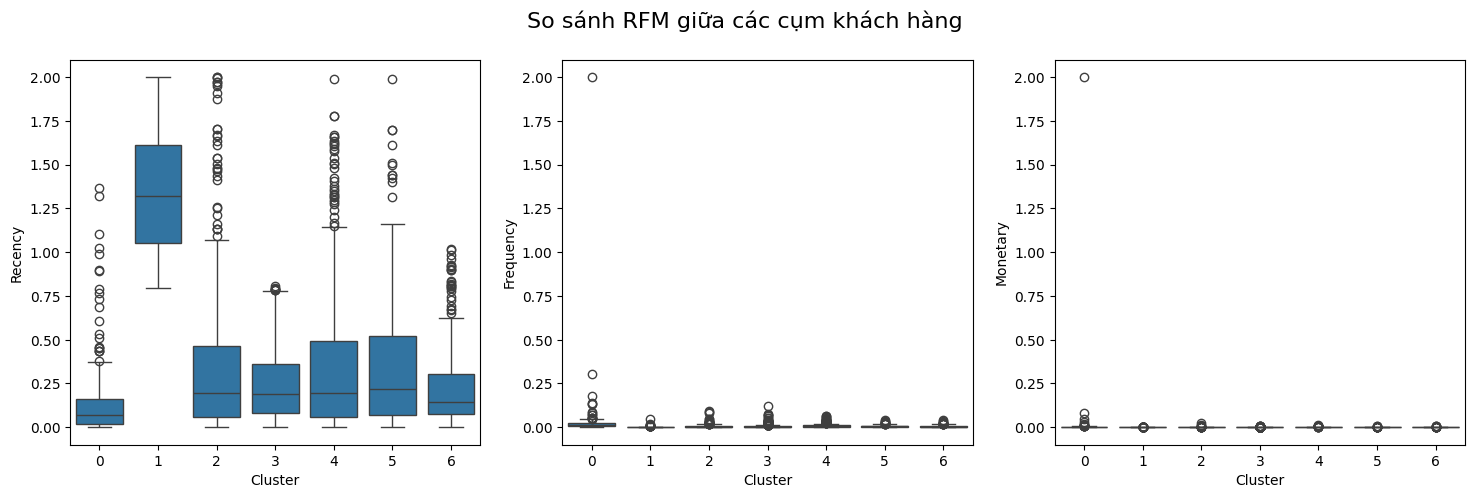

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
# Tính giá trị trung bình của các đặc trưng theo từng cụm
cluster_summary = results.groupby('Cluster').mean()

# Nếu bạn có cột RFM, nó sẽ hiện Recency, Frequency, Monetary trung bình
# Nếu chỉ có Rule, nó sẽ hiện tỉ lệ thỏa mãn luật
print(">>> BẢNG THỐNG KÊ TRUNG BÌNH CÁC CỤM (Dùng để so sánh):")
display(cluster_summary)

# Vẽ biểu đồ Boxplot cho RFM (nếu có) để dễ nhìn sự khác biệt
if 'Monetary' in results.columns:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.boxplot(x='Cluster', y='Recency', data=results, ax=axes[0])
    sns.boxplot(x='Cluster', y='Frequency', data=results, ax=axes[1])
    sns.boxplot(x='Cluster', y='Monetary', data=results, ax=axes[2])
    plt.suptitle('So sánh RFM giữa các cụm khách hàng', fontsize=16)
    plt.show()

In [29]:
def get_top_rules_for_cluster(cluster_id, summary_df, rules_df, top_n=3):
    """
    Hàm tìm top luật phổ biến nhất trong một cụm
    """
    # Lấy dòng dữ liệu của cụm đó
    cluster_data = summary_df.loc[cluster_id]
    
    # Lọc ra các cột là Rule (bỏ qua cột RFM)
    rule_cols = [c for c in cluster_data.index if c.startswith('Rule_')]
    
    # Sắp xếp xem Rule nào có giá trị cao nhất trong cụm này
    top_rules_indices = cluster_data[rule_cols].sort_values(ascending=False).head(top_n).index
    
    print(f"\n ĐẶC TRƯNG CỦA CỤM {cluster_id}:")
    for r_col in top_rules_indices:
        # Lấy index của luật (VD: Rule_10 -> lấy số 10)
        idx = int(r_col.split('_')[1])
        
        # Tra cứu thông tin luật trong bảng rules gốc
        rule_info = rules_df.iloc[idx]
        score = cluster_data[r_col]
        
        if score > 0.01: # Chỉ hiện nếu ít nhất 1% khách trong cụm tuân theo
            print(f"   - {r_col} (Thỏa mãn {score*100:.1f}%): Khách mua {list(rule_info['antecedents'])} ---> Thường mua thêm {list(rule_info['consequents'])}")
        else:
            print(f"   - (Không có luật nào quá nổi bật trong top {top_n})")

# Chạy vòng lặp để in thông tin cho tất cả các cụm
n_clusters = results['Cluster'].nunique()
for k in range(n_clusters):
    get_top_rules_for_cluster(k, cluster_summary, df_rules)


 ĐẶC TRƯNG CỦA CỤM 0:
   - Rule_0 (Thỏa mãn 99.5%): Khách mua ['GREEN REGENCY TEACUP AND SAUCER'] ---> Thường mua thêm ['f', 'r', 'o', 'z', 'e', 'n', 's', 'e', 't', '(', '{', "'", 'P', 'I', 'N', 'K', ' ', 'R', 'E', 'G', 'E', 'N', 'C', 'Y', ' ', 'T', 'E', 'A', 'C', 'U', 'P', ' ', 'A', 'N', 'D', ' ', 'S', 'A', 'U', 'C', 'E', 'R', "'", '}', ')']
   - Rule_4 (Thỏa mãn 99.5%): Khách mua ['GARDENERS KNEELING PAD CUP OF TEA '] ---> Thường mua thêm ['f', 'r', 'o', 'z', 'e', 'n', 's', 'e', 't', '(', '{', "'", 'G', 'A', 'R', 'D', 'E', 'N', 'E', 'R', 'S', ' ', 'K', 'N', 'E', 'E', 'L', 'I', 'N', 'G', ' ', 'P', 'A', 'D', ' ', 'K', 'E', 'E', 'P', ' ', 'C', 'A', 'L', 'M', ' ', "'", '}', ')']
   - Rule_6 (Thỏa mãn 99.5%): Khách mua ['GREEN REGENCY TEACUP AND SAUCER'] ---> Thường mua thêm ['f', 'r', 'o', 'z', 'e', 'n', 's', 'e', 't', '(', '{', "'", 'R', 'O', 'S', 'E', 'S', ' ', 'R', 'E', 'G', 'E', 'N', 'C', 'Y', ' ', 'T', 'E', 'A', 'C', 'U', 'P', ' ', 'A', 'N', 'D', ' ', 'S', 'A', 'U', 'C', 'E', 'R', 

In [30]:
# Lưu bảng kết quả cuối cùng có nhãn cụm
output_path = '../data/processed/customer_segments.csv'
results.to_csv(output_path)
print(f"✅ Đã lưu kết quả phân cụm vào: {output_path}")

# (Tùy chọn) Lưu bảng thống kê để vẽ biểu đồ báo cáo
cluster_summary.to_csv('../data/processed/cluster_profile_summary.csv')

✅ Đã lưu kết quả phân cụm vào: ../data/processed/customer_segments.csv
